# EDA on International T20 Dataset



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("International_T20_Data.csv", engine="python", on_bad_lines="skip")

df.head()

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.rename(columns={
    'meta.created':'created_date',
    'meta.data_version':'data_version',
    'info.city':'city',
    'info.venue':'venue',
    'info.teams':'teams',
    'info.outcome.winner':'winner',
    'info.toss.winner':'toss_winner',
    'info.toss.decision':'toss_decision'
})

df.columns

Index(['innings', 'data_version', 'created_date', 'meta.revision',
       'info.dates', 'info.gender', 'info.match_type',
       'info.outcome.by.wickets', 'winner', 'info.overs',
       'info.player_of_match', 'teams', 'toss_decision', 'toss_winner',
       'info.umpires', 'venue', 'city', 'info.outcome.by.runs',
       'info.match_type_number', 'info.neutral_venue', 'info.outcome.method',
       'info.outcome.result', 'info.outcome.eliminator',
       'info.supersubs.New Zealand', 'info.supersubs.South Africa',
       'info.bowl_out', 'info.outcome.bowl_out'],
      dtype='object')

In [ ]:
columns_table = pd.DataFrame(df.columns, columns=["Column Names"])
columns_table.index = columns_table.index + 1
columns_table

,Column Names
1,innings
2,data_version
3,created_date
4,meta.revision
5,info.dates
6,info.gender
7,info.match_type
8,info.outcome.by.wickets
9,winner
10,info.overs


In [ ]:
top_venues = df['venue'].value_counts().head(3).reset_index()
top_venues.columns = ['Venue', 'Number_of_Matches']

top_venues

,Venue,Number_of_Matches
0,Dubai International Cricket Stadium,62
1,Sheikh Zayed Stadium,41
2,Shere Bangla National Stadium,39


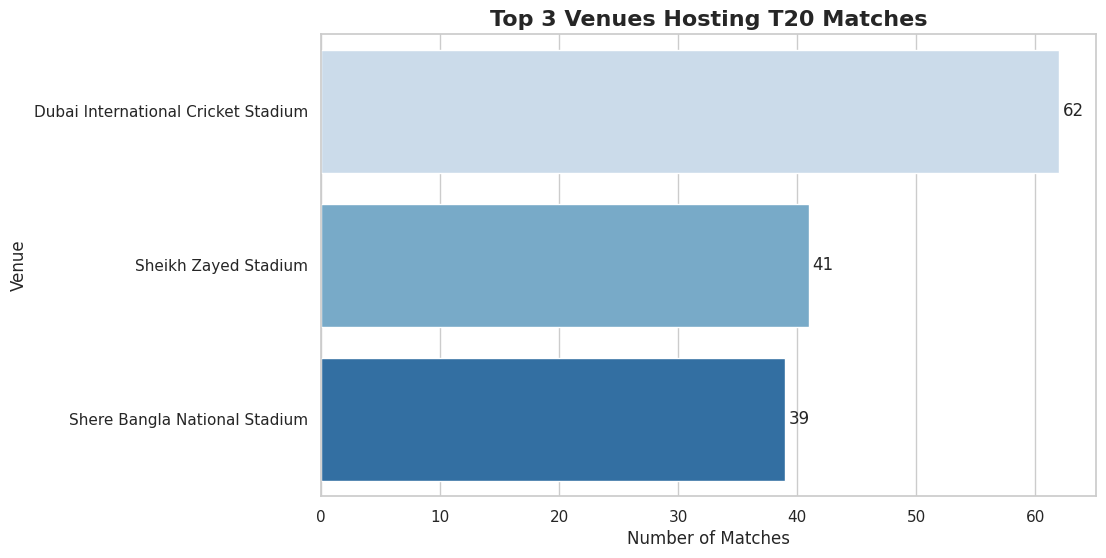

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_venues,
    x="Number_of_Matches",
    y="Venue",
    hue="Venue",
    palette="Blues",
    legend=False
)

plt.title("Top 3 Venues Hosting T20 Matches", fontsize=16, weight="bold")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

for i,v in enumerate(top_venues["Number_of_Matches"]):
    ax.text(v+0.3,i,str(v),va="center")

plt.show()

In [ ]:
df['teams'] = df['teams'].str.replace('[','',regex=False)\
                         .str.replace(']','',regex=False)\
                         .str.replace("'","",regex=False)

In [ ]:
df[['team1','team2']] = df['teams'].str.split(',',expand=True)

df['team1'] = df['team1'].str.strip()
df['team2'] = df['team2'].str.strip()

In [ ]:
df['team_pair'] = df.apply(lambda x: tuple(sorted([x['team1'],x['team2']])),axis=1)

pair_counts = df['team_pair'].value_counts()

top_pairs = pair_counts.head(5).reset_index()
top_pairs.columns = ["Team Pair","Matches Played"]

top_pairs["Team Pair"] = top_pairs["Team Pair"].astype(str)

top_pairs

,Team Pair,Matches Played
0,"('Australia', 'England')",45
1,"('Australia', 'Pakistan')",33
2,"('England', 'West Indies')",33
3,"('Australia', 'India')",32
4,"('England', 'Pakistan')",31


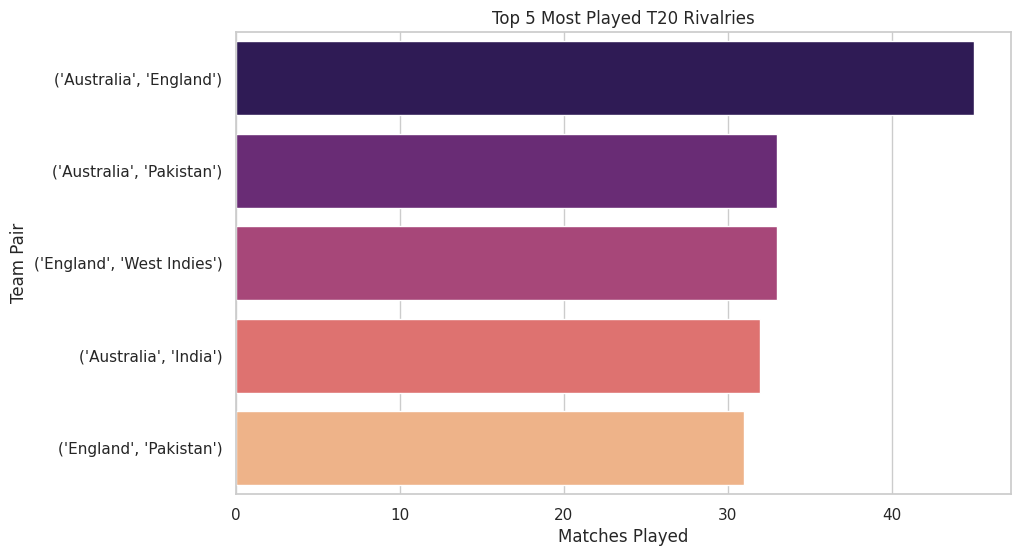

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_pairs,
    x="Matches Played",
    y="Team Pair",
    hue="Team Pair",
    palette="magma",
    legend=False
)

plt.title("Top 5 Most Played T20 Rivalries")
plt.xlabel("Matches Played")
plt.ylabel("Team Pair")

plt.show()

In [ ]:
team_matches = {}

for t1,t2 in zip(df['team1'],df['team2']):
    team_matches[t1] = team_matches.get(t1,0)+1
    team_matches[t2] = team_matches.get(t2,0)+1

In [ ]:
team_wins = df['winner'].value_counts().to_dict()

In [ ]:
win_percentage = {}

for team in team_matches:

    wins = team_wins.get(team,0)
    matches = team_matches[team]

    win_percentage[team] = (wins/matches)*100

In [ ]:
win_df = pd.DataFrame(list(win_percentage.items()),
                      columns=["Team","Win Percentage"])

In [ ]:
win_df = pd.DataFrame(list(win_percentage.items()),
                      columns=["Team","Win Percentage"])

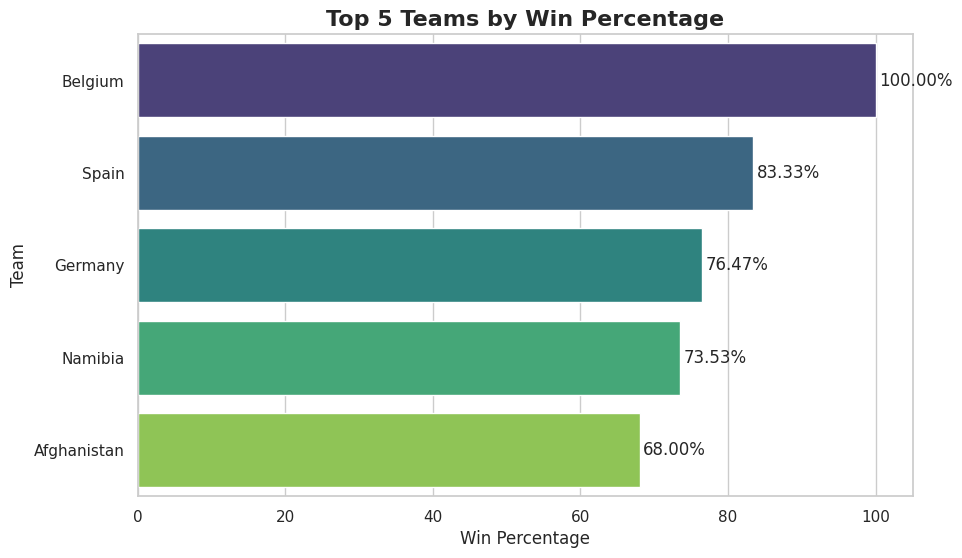

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top5,
    x="Win Percentage",
    y="Team",
    hue="Team",
    palette="viridis",
    legend=False
)

plt.title("Top 5 Teams by Win Percentage",fontsize=16,weight="bold")

for i,v in enumerate(top5["Win Percentage"]):
    ax.text(v+0.5,i,f"{v:.2f}%",va="center")

plt.show()

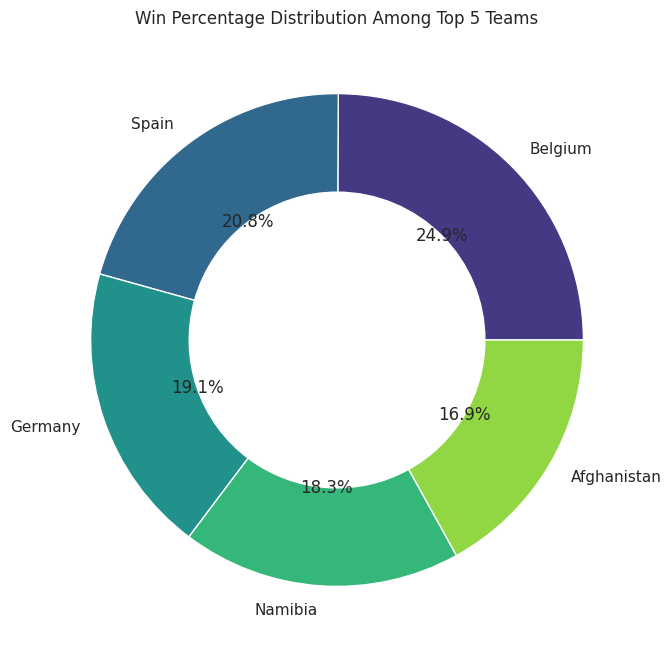

In [ ]:
plt.figure(figsize=(8,8))

colors = sns.color_palette("viridis",len(top5))

plt.pie(
    top5["Win Percentage"],
    labels=top5["Team"],
    autopct="%1.1f%%",
    colors=colors,
    wedgeprops={'width':0.4}
)

plt.title("Win Percentage Distribution Among Top 5 Teams")

plt.show()

In [ ]:
df['innings'] = df['innings'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x,str) else x
)

In [ ]:
def get_scorecard(innings):

    bat_first = {}
    bat_second = {}
    bowl_first = {}
    bowl_second = {}

    # first innings
    first_deliveries = innings[0]['1st innings']['deliveries']

    for delivery in first_deliveries:

        ball = list(delivery.values())[0]

        batter = ball['batsman']
        bowler = ball['bowler']
        runs = ball['runs']['batsman']

        bat_first[batter] = bat_first.get(batter,0)+runs
        bowl_second[bowler] = bowl_second.get(bowler,0)+runs


    # second innings
    second_deliveries = innings[1]['2nd innings']['deliveries']

    for delivery in second_deliveries:

        ball = list(delivery.values())[0]

        batter = ball['batsman']
        bowler = ball['bowler']
        runs = ball['runs']['batsman']

        bat_second[batter] = bat_second.get(batter,0)+runs
        bowl_first[bowler] = bowl_first.get(bowler,0)+runs


    bat_df1 = pd.DataFrame(bat_first.items(),
                           columns=["Batsman","Runs"])\
                           .sort_values(by="Runs",
                                        ascending=False).head(4)

    bowl_df1 = pd.DataFrame(bowl_second.items(),
                            columns=["Bowler","Runs Conceded"])\
                            .sort_values(by="Runs Conceded").head(4)

    bat_df2 = pd.DataFrame(bat_second.items(),
                           columns=["Batsman","Runs"])\
                           .sort_values(by="Runs",
                                        ascending=False).head(4)

    bowl_df2 = pd.DataFrame(bowl_first.items(),
                            columns=["Bowler","Runs Conceded"])\
                            .sort_values(by="Runs Conceded").head(4)

    scorecard1 = pd.concat([bat_df1.reset_index(drop=True),
                            bowl_df1.reset_index(drop=True)],axis=1)

    scorecard2 = pd.concat([bat_df2.reset_index(drop=True),
                            bowl_df2.reset_index(drop=True)],axis=1)

    return scorecard1,scorecard2

In [ ]:
score1,score2 = get_scorecard(df['innings'][0])

score1

,Batsman,Runs,Bowler,Runs Conceded
0,AJ Finch,43,DAS Gunaratne,11
1,M Klinger,38,S Prasanna,22
2,TM Head,31,SL Malinga,28
3,AJ Turner,18,PADLR Sandakan,30


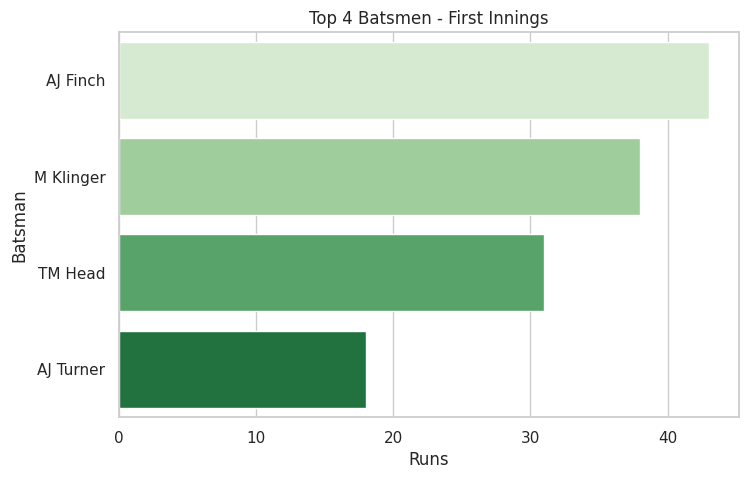

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=score1,
    x="Runs",
    y="Batsman",
    hue="Batsman",
    palette="Greens",
    legend=False
)

plt.title("Top 4 Batsmen - First Innings")

plt.show()

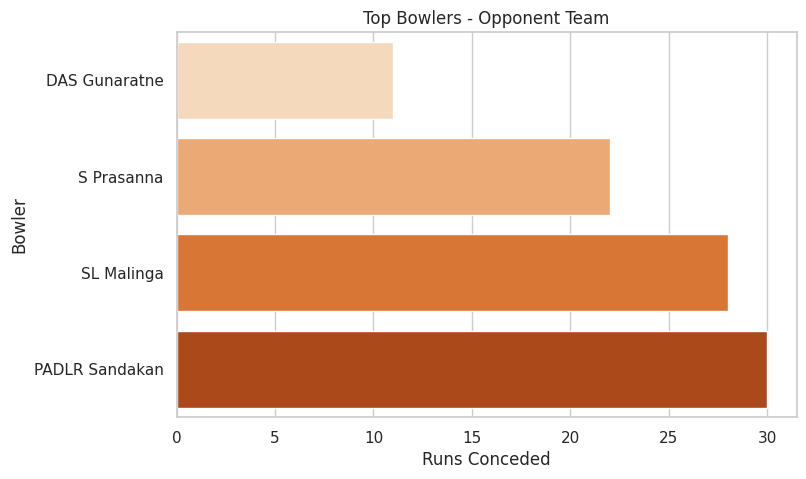

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=score1,
    x="Runs Conceded",
    y="Bowler",
    hue="Bowler",
    palette="Oranges",
    legend=False
)

plt.title("Top Bowlers - Opponent Team")

plt.show()

## **Libraries- Numpy, Pandas,Matpotlib**

# Numpy

In [ ]:
# Load the Numpy
import numpy as np

In [ ]:
# Create a 2 D Array
arravali = np.array(np.random.randint(10,45,(8,2)))
print(f"The defined array is \n{arravali}")
print(f" \n The shape of the array is {arravali.shape}")

The defined array is 
[[24 27]
 [17 27]
 [36 24]
 [11 15]
 [30 24]
 [24 12]
 [36 31]
 [42 14]]
 
 The shape of the array is (8, 2)


In [ ]:
# Storing the transpose in another matrix object
nilgiri =np.transpose(arravali)
print(f" The transpose of the array is \n{nilgiri}")
print(f" \n The shape of the array is {nilgiri.shape}")

 The transpose of the array is 
[[24 17 36 11 30 24 36 42]
 [27 27 24 15 24 12 31 14]]
 
 The shape of the array is (2, 8)


In [ ]:
# 3D Array
random_3d_array = np.array(np.random.randint(10,45,(3,2,4)))
print(f"The defined array is \n{random_3d_array}")
print(f" \n The shape of the array is {random_3d_array.shape}")

The defined array is 
[[[29 26 20 36]
  [17 44 37 30]]

 [[34 43 35 12]
  [33 33 39 15]]

 [[18 40 34 34]
  [41 25 29 42]]]
 
 The shape of the array is (3, 2, 4)


In [ ]:
# Storing the transpose of the created 3d array
transposed_3d_array =np.transpose(random_3d_array)
print(f" The transpose of the array is \n{transposed_3d_array}")
print(f" \n The shape of the array is {transposed_3d_array.shape}")

 The transpose of the array is 
[[[29 34 18]
  [17 33 41]]

 [[26 43 40]
  [44 33 25]]

 [[20 35 34]
  [37 39 29]]

 [[36 12 34]
  [30 15 42]]]
 
 The shape of the array is (4, 2, 3)


In [ ]:
# Create a two-dimensional array
random_cohort = np.array(np.random.randint(10,45,(3,8))) # 2D
print(f"The defined array is \n{random_cohort}")
print(f" \n The shape of the array is {random_cohort.shape}")

The defined array is 
[[43 16 40 19 38 18 30 33]
 [11 28 33 37 42 24 13 11]
 [37 19 42 31 43 15 24 28]]
 
 The shape of the array is (3, 8)


In [ ]:
# Now we can reshape this to 1-D,2-D or 3-D array
new_shape = (2,6,2)
reshaped_random_cohort = np.reshape(random_cohort,new_shape)
print(f"The reshaped array is \n{reshaped_random_cohort}")
print(f" \n The shape of the array is {reshaped_random_cohort.shape}")

The reshaped array is 
[[[43 16]
  [40 19]
  [38 18]
  [30 33]
  [11 28]
  [33 37]]

 [[42 24]
  [13 11]
  [37 19]
  [42 31]
  [43 15]
  [24 28]]]
 
 The shape of the array is (2, 6, 2)


In [ ]:
new_shape = (2,-1,6)
reshaped_random_cohort = np.reshape(random_cohort,new_shape)
print(f"The reshaped array is \n{reshaped_random_cohort}")
print(f" \n The shape of the array is {reshaped_random_cohort.shape}")

The reshaped array is 
[[[43 16 40 19 38 18]
  [30 33 11 28 33 37]]

 [[42 24 13 11 37 19]
  [42 31 43 15 24 28]]]
 
 The shape of the array is (2, 2, 6)


In [ ]:
# Create a three-dimensional array
random_3D_cohort = np.array(np.random.randint(10,45,(3,6,2)))
print(f"The defined array is \n{random_3D_cohort}")
print(f" \n The shape of the array is {random_3D_cohort.shape}")

The defined array is 
[[[38 18]
  [44 12]
  [16 13]
  [16 18]
  [20 27]
  [23 22]]

 [[28 14]
  [17 28]
  [38 32]
  [10 37]
  [25 41]
  [12 29]]

 [[22 34]
  [17 18]
  [13 35]
  [15 20]
  [38 13]
  [44 30]]]
 
 The shape of the array is (3, 6, 2)


In [ ]:
# Reshape the created 3D array
new_shape = (2,-1,6)
reshaped_random_3D_cohort = np.reshape(random_3D_cohort,new_shape)
print(f"The reshaped array is \n{reshaped_random_3D_cohort}")
print(f" \n The shape of the array is {reshaped_random_3D_cohort.shape}")

The reshaped array is 
[[[38 18 44 12 16 13]
  [16 18 20 27 23 22]
  [28 14 17 28 38 32]]

 [[10 37 25 41 12 29]
  [22 34 17 18 13 35]
  [15 20 38 13 44 30]]]
 
 The shape of the array is (2, 3, 6)


In [ ]:
# Intialize a 3D array
random_3D_cohort = np.array(np.random.randint(10,45,(2,4,6)))
print(f"The defined array is \n{random_3D_cohort}")
print(f" \n The shape of the array is {random_3D_cohort.shape}")

The defined array is 
[[[19 37 16 22 19 23]
  [27 31 23 27 14 38]
  [34 20 27 40 13 39]
  [13 33 28 16 17 15]]

 [[25 41 38 43 35 23]
  [41 20 33 39 15 35]
  [31 40 36 10 12 17]
  [36 26 24 10 40 22]]]
 
 The shape of the array is (2, 4, 6)


In [ ]:
# Resize the created 3D array
new_shape = (2,3,6)
resized_random_3D_cohort = np.resize(random_3D_cohort,new_shape)
print(f"The resized array is \n{resized_random_3D_cohort}")
print(f" \n The shape of the array is {resized_random_3D_cohort.shape}")

The resized array is 
[[[19 37 16 22 19 23]
  [27 31 23 27 14 38]
  [34 20 27 40 13 39]]

 [[13 33 28 16 17 15]
  [25 41 38 43 35 23]
  [41 20 33 39 15 35]]]
 
 The shape of the array is (2, 3, 6)


In [ ]:
# Intialize a 3D array
random_3D_cohort = np.array(np.random.randint(10,45,(2,4,6)))
print(f"The defined array is \n{random_3D_cohort}")
print(f" \n The shape of the array is {random_3D_cohort.shape}")

The defined array is 
[[[27 29 24 26 10 24]
  [11 27 35 43 44 33]
  [23 41 26 43 26 19]
  [31 11 23 18 44 25]]

 [[26 16 40 28 35 10]
  [25 26 20 19 13 12]
  [35 18 41 24 37 21]
  [34 24 39 21 12 40]]]
 
 The shape of the array is (2, 4, 6)


In [ ]:
a = np.random.randint(10,20,(2,3,4))    # Axis 0 - 2 ; Axis 1 - 3 ; Axis 2 - 4
print(a)
print(a.shape)

[[[14 12 15 12]
  [18 18 10 19]
  [17 16 18 15]]

 [[14 14 13 18]
  [11 17 16 19]
  [19 16 11 11]]]
(2, 3, 4)


In [ ]:
#Insert along axis =0
np.insert(a,1,100,axis=0)

array([[[ 14,  12,  15,  12],
        [ 18,  18,  10,  19],
        [ 17,  16,  18,  15]],

       [[100, 100, 100, 100],
        [100, 100, 100, 100],
        [100, 100, 100, 100]],

       [[ 14,  14,  13,  18],
        [ 11,  17,  16,  19],
        [ 19,  16,  11,  11]]])

In [ ]:
# Insert along axis = 1
np.insert(a,0,50,axis=1)

array([[[50, 50, 50, 50],
        [14, 12, 15, 12],
        [18, 18, 10, 19],
        [17, 16, 18, 15]],

       [[50, 50, 50, 50],
        [14, 14, 13, 18],
        [11, 17, 16, 19],
        [19, 16, 11, 11]]])

In [ ]:
# Insert along axis=2
np.insert(a,0,200,axis=2)

array([[[200,  14,  12,  15,  12],
        [200,  18,  18,  10,  19],
        [200,  17,  16,  18,  15]],

       [[200,  14,  14,  13,  18],
        [200,  11,  17,  16,  19],
        [200,  19,  16,  11,  11]]])

In [ ]:
a = np.random.randint(2,6,(2,3,3))
print(a)
print(a.shape)

[[[3 4 5]
  [5 2 5]
  [4 3 4]]

 [[4 4 4]
  [4 5 5]
  [2 3 3]]]
(2, 3, 3)


In [ ]:
 # Append a value to the array. It flattens the array and append -99 to the end
np.append(a, 50)

array([ 3,  4,  5,  5,  2,  5,  4,  3,  4,  4,  4,  4,  4,  5,  5,  2,  3,
        3, 50])

In [ ]:
# Fix the axis other than axis of appending
b = np.random.randint(2,6,(2,1,3))
print(b)

[[[4 3 4]]

 [[2 4 5]]]


In [ ]:
print(a)
print(a.shape)

[[[3 4 5]
  [5 2 5]
  [4 3 4]]

 [[4 4 4]
  [4 5 5]
  [2 3 3]]]
(2, 3, 3)


In [ ]:
a = np.random.randint(2,6,(2,3,3))
print(a)
print(a.shape)

[[[5 5 5]
  [4 3 3]
  [4 2 3]]

 [[4 3 4]
  [3 3 5]
  [2 3 3]]]
(2, 3, 3)


In [ ]:
# Delete along Axis=0
np.delete(a,(0),axis = 0)

array([[[4, 3, 4],
        [3, 3, 5],
        [2, 3, 3]]])

In [ ]:
# Delete along axis=1
np.delete(a,(0,2),axis = 1)

array([[[4, 3, 3]],

       [[3, 3, 5]]])

In [ ]:
# Delete along axis=2
np.delete(a,(0,1),axis = 2)

array([[[5],
        [3],
        [3]],

       [[4],
        [5],
        [3]]])

In [ ]:
#Initialized array
a = np.random.randint(2,20,(2,3,3))
print(a)
print(a.shape)

[[[17 16  5]
  [17 16 13]
  [11 12 12]]

 [[ 6  7  2]
  [14  9 15]
  [ 5  6  7]]]
(2, 3, 3)


In [ ]:
# return_counts= True
np.unique(a,return_counts=True) # Returns tuple

(array([ 2,  5,  6,  7,  9, 11, 12, 13, 14, 15, 16, 17]),
 array([1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2]))

In [ ]:
# return_index = True
np.unique(a,return_counts=True,return_index=True)

(array([ 2,  5,  6,  7,  9, 11, 12, 13, 14, 15, 16, 17]),
 array([11,  2,  9, 10, 13,  6,  7,  5, 12, 14,  1,  0]),
 array([1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2]))

In [ ]:
# Lets take an example of a list
a = [1,2,3]
b = a
b[0] = 10
print(b)
print(a)

[10, 2, 3]
[10, 2, 3]


In [ ]:
# Lets use the copy method
a = [1,2,3]
b = a.copy()
b[0] = 10
print(b)
print(a)

[10, 2, 3]
[1, 2, 3]


In [ ]:
a = np.array([2,34,12])
b = a
b[0] = -999
print(b)
print(a)

[-999   34   12]
[-999   34   12]


In [ ]:
a = np.array([2,34,12])
b = a.copy()
b[0] = -999
print(b)
print(a)

[-999   34   12]
[ 2 34 12]


In [ ]:
np.arange(3) + 5

array([5, 6, 7])

In [ ]:
np.ones((3,3)) + np.arange(3)

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

In [ ]:
np.arange(3).reshape((3,1)) + np.arange(3)

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

In [ ]:
np.arange(3).reshape((3,1)) + np.arange(4)

array([[0, 1, 2, 3],
       [1, 2, 3, 4],
       [2, 3, 4, 5]])

In [ ]:
 np.arange(2)

array([0, 1])

In [ ]:
#Example 2
a=np.random.randint(2,6,(2,4))
print(a)
b=np.random.randint(1,10,(2,2))
print(b)

[[4 2 4 4]
 [4 4 4 4]]
[[3 8]
 [7 5]]


In [ ]:
a=np.random.randint(2,6,(2,4))
print(a)
b=np.random.randint(0,5,(2,4))
print(b)

[[2 4 4 5]
 [5 4 4 4]]
[[3 3 0 4]
 [1 1 3 3]]


In [ ]:
np.multiply(a,b)

array([[ 6, 12,  0, 20],
       [ 5,  4, 12, 12]])

In [ ]:
np.divide(a,b)

/tmp/ipykernel_431/2626738034.py:1: RuntimeWarning: divide by zero encountered in divide
  np.divide(a,b)


array([[0.66666667, 1.33333333,        inf, 1.25      ],
       [5.        , 4.        , 1.33333333, 1.33333333]])

In [ ]:
a=np.random.randint(5,9,(2,4))
print(a)

[[7 7 8 6]
 [8 6 6 5]]


In [ ]:
print(np.sum(a))
print(np.sum(a,axis=0))
print(np.sum(a,axis=1))

53
[15 13 14 11]
[28 25]


In [ ]:
# Sort the array
a=np.random.randint(0,20,(3,3))
print(a)

[[15  2  2]
 [ 2  5 18]
 [18  0  0]]


In [ ]:
print(np.sort(a,axis=0)) # Ascending

[[ 2  0  0]
 [15  2  2]
 [18  5 18]]


In [ ]:
print(np.sort(a,axis=1))

[[ 2  2 15]
 [ 2  5 18]
 [ 0  0 18]]


In [ ]:
print(-np.sort(-a,axis=1)) # Descending

[[15  2  2]
 [18  5  2]
 [18  0  0]]


In [ ]:
sum(np.arange(3)*np.arange(3).transpose())

np.int64(5)

# Panda

In [ ]:
# Import pandas package
import pandas as pd
import numpy as np

In [ ]:
# loading csv File
file_path = 'imdb_data.csv'
df=pd.read_csv(file_path)

In [ ]:
df.shape

(3000, 23)

In [ ]:
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [ ]:
df.tail(10)

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
2990,2991,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",NaN,tt0118663,en,B.A.P.S.,Can two clueless Georgia homegirls with big he...,1.560980,...,3/28/97,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,These Pretty Women... Are Clueless!,B.A.P.S.,"[{'id': 1437, 'name': 'burglar'}, {'id': 1946,...","[{'cast_id': 3, 'character': 'Nisi', 'credit_i...","[{'credit_id': '52fe477b9251416c7509af57', 'de...",7240837
2991,2992,"[{'id': 107469, 'name': 'Save The Last Dance C...",13000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",NaN,tt0206275,en,Save the Last Dance,"A white midwestern girl moves to Chicago, wher...",4.794088,...,1/12/01,112.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Only Person You Need To Be Is Yourself.,Save the Last Dance,"[{'id': 4118, 'name': 'ballet dancer'}, {'id':...","[{'cast_id': 18, 'character': 'Sara Johnson', ...","[{'credit_id': '52fe4533c3a36847f80c1c6b', 'de...",91038276
2992,2993,NaN,1135654,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,tt0015400,en,The Thief of Bagdad,A recalcitrant thief vies with a duplicitous M...,3.878515,...,3/18/24,149.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,"""Happiness Must Be Earned""",The Thief of Bagdad,"[{'id': 255, 'name': 'male nudity'}, {'id': 14...","[{'cast_id': 3, 'character': 'The Thief of Bag...","[{'credit_id': '52fe45bec3a368484e06c70b', 'de...",1213880
2993,2994,NaN,60000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.theterminal-themovie.com/,tt0362227,en,The Terminal,Viktor Navorski is a man without a country; hi...,14.092373,...,6/17/04,128.0,"[{'iso_639_1': 'bg', 'name': 'български език'}...",Released,Life is waiting.,The Terminal,"[{'id': 242, 'name': 'new york'}, {'id': 822, ...","[{'cast_id': 4, 'character': 'Viktor Navorski'...","[{'credit_id': '52fe4259c3a36847f8017699', 'de...",219417255
2994,2995,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,tt0105327,en,School Ties,When David Greene receives a football scholars...,7.438381,...,9/18/92,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just because you’re accepted doesn’t mean you ...,School Ties,"[{'id': 6075, 'name': 'sport'}, {'id': 10144, ...","[{'cast_id': 2, 'character': 'David Greene', '...","[{'credit_id': '5637777ac3a3681b4d01f9f5', 'de...",14715067
2995,2996,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0109403,en,Chasers,Military men Rock Reilly and Eddie Devane are ...,9.853270,...,4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It was supposed to be a routine prisoner trans...,Chasers,"[{'id': 378, 'name': 'prison'}, {'id': 572, 'n...","[{'cast_id': 2, 'character': 'Rock Reilly', 'c...","[{'credit_id': '52fe4494c3a368484e02ac7d', 'de...",1596687
2996,2997,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,tt2364975,sv,Vi är bäst!,Three girls in 1980s Stockholm decide to form ...,3.727996,...,3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",Released,NaN,We Are the Best!,"[{'id': 1192, 'name': 'sweden'}, {'id': 4470, ...","[{'cast_id': 5, 'character': 'Bobo', 'credit_i...","[{'credit_id': '5716b72ac3a3686678012c84', 'de...",180590
2997,2998,NaN,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,tt0116908,en,The Long Kiss Goodnight,"Samantha Caine, suburban homemaker, is the ide...",14.482345,...,10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,What's forgotten is not always gone.,The Long Kiss Goodnight,"[{'id': 441, 'name': 'assassination'}, {'id': ...","[{'cast_id': 10, 'character': 'Samantha Caine ...","[{'credit_id': '52fe443a9251416c7502d579', 'de...",89456761
2998,2999,NaN,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www.alongcamepolly.com/,tt0343135,en,Along Came Polly,Reuben Feffer is a 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

In [ ]:
df.describe()

,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


In [ ]:
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [ ]:
# Let us get a subset which consists of first 8 rows and first 4 columns
df.iloc[:,-3:]

,cast,crew,revenue
0,"[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,"[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,"[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,"[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970
...,...,...,...
2995,"[{'cast_id': 2, 'character': 'Rock Reilly', 'c...","[{'credit_id': '52fe4494c3a368484e02ac7d', 'de...",1596687
2996,"[{'cast_id': 5, 'character': 'Bobo', 'credit_i...","[{'credit_id': '5716b72ac3a3686678012c84', 'de...",180590
2997,"[{'cast_id': 10, 'character': 'Samantha Caine ...","[{'credit_id': '52fe443a9251416c7502d579', 'de...",89456761
2998,"[{'cast_id': 8, 'character': 'Reuben Feffer', ...","[{'credit_id': '556f817b9251410866000a63', 'de...",171963386


In [ ]:
# Now let us subset our dataframe in which we want to have first 8 rows identified with their rows labels and some named columns
df.loc[50:60,['budget','genres','runtime']]

,budget,genres,runtime
50,560000,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",102.0
51,12000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 35, '...",160.0
52,0,"[{'id': 12, 'name': 'Adventure'}, {'id': 10751...",97.0
53,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",98.0
54,20000000,"[{'id': 28, 'name': 'Action'}]",107.0
55,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",95.0
56,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",97.0
57,125000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",125.0
58,0,"[{'id': 10402, 'name': 'Music'}, {'id': 10749,...",95.0
59,14000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",95.0


In [ ]:
df.loc[:,['budget','genres','runtime']]

,budget,genres,runtime
0,14000000,"[{'id': 35, 'name': 'Comedy'}]",93.0
1,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",113.0
2,3300000,"[{'id': 18, 'name': 'Drama'}]",105.0
3,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",122.0
4,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",118.0
...,...,...,...
2995,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",102.0
2996,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",102.0
2997,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",120.0
2998,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",90.0


In [ ]:
df[0:10]

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970
5,6,NaN,8000000,"[{'id': 16, 'name': 'Animation'}, {'id': 12, '...",NaN,tt0093743,en,Pinocchio and the Emperor of the Night,"Pinocchio and his friends, a glow worm and a m...",0.743274,...,8/6/87,83.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Pinocchio and the Emperor of the Night,NaN,"[{'cast_id': 6, 'character': 'Pinocchio (voice...","[{'credit_id': '52fe46f49251416c9106558b', 'de...",3261638
6,7,NaN,14000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",http://www.thepossessionmovie.com/,tt0431021,en,The Possession,A young girl buys an antique box at a yard sal...,7.286477,...,8/30/12,92.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Fear The Demon That Doesn't Fear God,The Possession,NaN,"[{'cast_id': 23, 'character': 'Clyde', 'credit...","[{'credit_id': '52fe4981c3a368484e12ee29', 'de...",85446075
7,8,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,tt0391024,en,Control Room,A chronicle which provides a rare window into ...,1.949044,...,1/15/04,84.0,"[{'iso_639_1': 'ar', 'name': 'العربية'}, {'iso...",Released,Different channels. Different truths.,Control Room,"[{'id': 917, 'name': 'journalism'}, {'id': 163...","[{'cast_id': 2, 'character': 'Himself', 'credi...","[{'credit_id': '52fe47a69251416c750a0daf', 'de...",2586511
8,9,"[{'id': 256377, 'name': 'The Muppet Collection...",0,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",NaN,tt0117110,en,Muppet Treasure Island,After telling the story of Flint's last journe...,6.902423,...,2/16/96,100.0,"[{'

In [ ]:
df[['original_language','release_date','cast']]

,original_language,release_date,cast
0,en,2/20/15,"[{'cast_id': 4, 'character': 'Lou', 'credit_id..."
1,en,8/6/04,"[{'cast_id': 1, 'character': 'Mia Thermopolis'..."
2,en,10/10/14,"[{'cast_id': 5, 'character': 'Andrew Neimann',..."
3,hi,3/9/12,"[{'cast_id': 1, 'character': 'Vidya Bagchi', '..."
4,ko,2/5/09,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred..."
...,...,...,...
2995,en,4/22/94,"[{'cast_id': 2, 'character': 'Rock Reilly', 'c..."
2996,sv,3/28/13,"[{'cast_id': 5, 'character': 'Bobo', 'credit_i..."
2997,en,10/11/96,"[{'cast_id': 10, 'character': 'Samantha Caine ..."
2998,en,1/16/04,"[{'cast_id': 8, 'character': 'Reuben Feffer', ..."


In [ ]:
df.columns

Index(['id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'],
      dtype='object')

In [ ]:
df['original_language'] == 'en'

,original_language
0,True
1,True
2,True
3,False
4,False
...,...
2995,True
2996,False
2997,True
2998,True


In [ ]:
# Boolean Indexing
english_movies = df[df['original_language'] == 'en']
english_movies.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
5,6,NaN,8000000,"[{'id': 16, 'name': 'Animation'}, {'id': 12, '...",NaN,tt0093743,en,Pinocchio and the Emperor of the Night,"Pinocchio and his friends, a glow worm and a m...",0.743274,...,8/6/87,83.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Pinocchio and the Emperor of the Night,NaN,"[{'cast_id': 6, 'character': 'Pinocchio (voice...","[{'credit_id': '52fe46f49251416c9106558b', 'de...",3261638
6,7,NaN,14000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",http://www.thepossessionmovie.com/,tt0431021,en,The Possession,A young girl buys an antique box at a yard sal...,7.286477,...,8/30/12,92.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Fear The Demon That Doesn't Fear God,The Possession,NaN,"[{'cast_id': 23, 'character': 'Clyde', 'credit...","[{'credit_id': '52fe4981c3a368484e12ee29', 'de...",85446075


In [ ]:
english_movies.shape

(2575, 23)

In [ ]:
non_english_movies = df[df['original_language'] != 'en']
non_english_movies.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970
15,16,NaN,500000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",http://skinningmovie.com/synopsis.htm,tt1129437,sr,Šišanje,Novica is a mathematics champion in a Belgrade...,1.018477,...,10/6/10,97.0,"[{'iso_639_1': 'sr', 'name': 'Srpski'}]",Released,Life is sometimes rude game: one mistake can b...,Skinning,"[{'id': 379, 'name': 'skinhead'}, {'id': 7492,...","[{'cast_id': 1001, 'character': 'Novica', 'cre...","[{'credit_id': '52fe4927c3a36847f818bb5f', 'de...",198
30,31,NaN,13000000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,tt1675434,fr,Intouchables,A true story of two men who should never have ...,16.086919,...,11/2/11,112.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Sometimes you have to reach into someone else'...,The Intouchables,"[{'id': 3230, 'name': 'male friendship'}, {'id...","[{'cast_id': 6, 'character': 'Philippe', 'cred...","[{'credit_id': '52fe4967c3a368484e129b63', 'de...",426480871
31,32,NaN,0,"[{'id': 9648, 'name': 'Mystery'}, {'id': 18, '...",http://www.cache-derfilm.at,tt0387898,fr,Caché,A married couple is terrorized by a series of ...,5.695860,...,5/2/05,117.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Caché,"[{'id': 90, 'name': 'paris'}, {'id': 213, 'nam...","[{'cast_id': 2, 'character': 'Georges Laurent'...","[{'credit_id': '52fe4244c3a36847f8011073', 'de...",36000000


In [ ]:
long_movies = df[df['runtime'] > 120]
long_movies[['title','cast']]

,title,cast
3,Kahaani,"[{'cast_id': 1, 'character': 'Vidya Bagchi', '..."
12,American Beauty,"[{'cast_id': 6, 'character': 'Lester Burnham',..."
14,Minority Report,"[{'cast_id': 5, 'character': 'Chief John Ander..."
20,Lost in Space,"[{'cast_id': 26, 'character': 'Dr. Zachary Smi..."
33,ABCs of Death 2,"[{'cast_id': 60, 'character': 'Assassin (Segme..."
...,...,...
2969,Gosford Park,"[{'cast_id': 2, 'character': 'Mrs. Wilson', 'c..."
2970,The Bodyguard,"[{'cast_id': 17, 'character': 'Rachel Marron',..."
2980,Action Hero Biju,"[{'cast_id': 1, 'character': 'Sub-Inspector Bi..."
2992,The Thief of Bagdad,"[{'cast_id': 3, 'character': 'The Thief of Bag..."


In [ ]:
long_movies = df[df['runtime'] > 120]

In [ ]:
long_movies.tail()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
2969,2970,NaN,19800000,"[{'id': 18, 'name': 'Drama'}, {'id': 9648, 'na...",NaN,tt0280707,en,Gosford Park,"Multiple storylined drama set in 1932, showing...",14.101101,...,11/7/01,137.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Tea at four. Dinner at eight. Murder at midnight.,Gosford Park,"[{'id': 964, 'name': 'servant'}, {'id': 10594,...","[{'cast_id': 2, 'character': 'Mrs. Wilson', 'c...","[{'credit_id': '52fe4401c3a36847f807ceab', 'de...",87754044
2970,2971,NaN,25000000,"[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'n...",NaN,tt0103855,en,The Bodyguard,A former Secret Service agent grudgingly takes...,9.805017,...,11/25/92,129.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Never let her out of your sight. Never let you...,The Bodyguard,"[{'id': 1156, 'name': 'sister sister relations...","[{'cast_id': 17, 'character': 'Rachel Marron',...","[{'credit_id': '52fe425ec3a36847f8019133', 'de...",411006740
2980,2981,NaN,300000,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",https://www.facebook.com/Actionherobiju/,tt5320514,ml,ആക്ഷൻ ഹീറോ ബിജു,Biju is an honest policeman who fights the inj...,0.350207,...,2/4/16,144.0,"[{'iso_639_1': 'ml', 'name': ''}]",Released,A ride with a police officer,Action Hero Biju,"[{'id': 1252, 'name': 'suicide attempt'}, {'id...","[{'cast_id': 1, 'character': 'Sub-Inspector Bi...","[{'credit_id': '56b4d47f92514112b90045f6', 'de...",2500000
2992,2993,NaN,1135654,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,tt0015400,en,The Thief of Bagdad,A recalcitrant thief vies with a duplicitous M...,3.878515,...,3/18/24,149.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,"""Happiness Must Be Earned""",The Thief of Bagdad,"[{'id': 255, 'name': 'male nudity'}, {'id': 14...","[{'cast_id': 3, 'character': 'The Thief of Bag...","[{'credit_id': '52fe45bec3a368484e06c70b', 'de...",1213880
2993,2994,NaN,60000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.theterminal-themovie.com/,tt0362227,en,The Terminal,Viktor Navorski is a man without a country; hi...,14.092373,...,6/17/04,128.0,"[{'iso_639_1': 'bg', 'name': 'български език'}...",Released,Life is waiting.,The Terminal,"[{'id': 242, 'name': 'new york'}, {'id': 822, ...","[{'cast_id': 4, 'character': 'Viktor Navorski'...","[{'credit_id': '52fe4259c3a36847f8017699', 'de...",219417255


In [ ]:
(df['original_language']=='en') & (df['runtime'] > 120)

,0
0,False
1,False
2,False
3,False
4,False
...,...
2995,False
2996,False
2997,False
2998,False


In [ ]:
long_english_movies = df[(df['original_language']=='en') & (df['runtime'] > 120)]
long_english_movies.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
12,13,NaN,15000000,"[{'id': 18, 'name': 'Drama'}]",http://www.dreamworks.com/ab/,tt0169547,en,American Beauty,"Lester Burnham, a depressed suburban father in...",20.726578,...,9/15/99,122.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Look closer.,American Beauty,"[{'id': 255, 'name': 'male nudity'}, {'id': 29...","[{'cast_id': 6, 'character': 'Lester Burnham',...","[{'credit_id': '52fe420ec3a36847f80007c5', 'de...",356296601
14,15,NaN,102000000,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt0181689,en,Minority Report,John Anderton is a top 'Precrime' cop in the l...,20.666063,...,6/20/02,145.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The system is perfect until it comes after you.,Minority Report,"[{'id': 476, 'name': 'self-fulfilling prophecy...","[{'cast_id': 5, 'character': 'Chief John Ander...","[{'credit_id': '52fe4223c3a36847f8006f3d', 'de...",358372926
20,21,NaN,80000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 10751...",NaN,tt0120738,en,Lost in Space,The prospects for continuing life on Earth in ...,12.000579,...,4/3/98,130.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"Danger, Will Robinson!",Lost in Space,"[{'id': 4379, 'name': 'time travel'}, {'id': 1...","[{'cast_id': 26, 'character': 'Dr. Zachary Smi...","[{'credit_id': '52fe433bc3a36847f80448b9', 'de...",136159423
33,34,"[{'id': 207632, 'name': 'The ABCs of Death Col...",0,"[{'id': 27, 'name': 'Horror'}]",NaN,tt2926810,en,ABCs of Death 2,Taking all that was great from the first insta...,8.254856,...,10/2/14,125.0,"[{'iso_639_1': 'ar', 'name': 'العربية'}, {'iso...",Released,Some people never learn,ABCs of Death 2,"[{'id': 9706, 'name': 'anthology'}, {'id': 187...","[{'cast_id': 60, 'character': 'Assassin (Segme...","[{'credit_id': '52fe4cd69251416c91101d73', 'de...",7171
37,38,NaN,50000000,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,tt0114069,en,Outbreak,A deadly airborne virus finds its way into the...,13.676444,...,3/10/95,127.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,This animal carries a deadly virus... and the ...,Outbreak,"[{'id': 1261, 'name': 'river'}, {'id': 1402, '...","[{'cast_id': 1, 'character': 'Sam Daniels', 'c...","[{'credit_id': '52fe446ac3a36847f80949d3', 'de...",189859560


In [ ]:
df['runtime']

,runtime
0,93.0
1,113.0
2,105.0
3,122.0
4,118.0
...,...
2995,102.0
2996,102.0
2997,120.0
2998,90.0


In [ ]:
# Add new column which is just half the runtime
df['half_runtime'] = df['runtime'] * 0.5

In [ ]:
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,half_runtime
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651,46.5
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435,56.5
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000,52.5
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000,61.0
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970,59.0


In [ ]:
# Creating another new column by subtracting/adding two existing columns
df['movie_profit'] = df['revenue'] - df['budget']

In [ ]:
# Remove column
df.drop(['id'], axis = 1, inplace=True)

In [ ]:
df.head()

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,half_runtime,movie_profit
0,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651,46.5,-1685349
1,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435,56.5,55149435
2,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000,52.5,9792000
3,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000,61.0,14800000
4,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970,59.0,3923970


In [ ]:
df.describe()

,budget,popularity,runtime,revenue,half_runtime,movie_profit
count,3.000000e+03,3000.000000,2998.000000,3.000000e+03,2998.000000,3.000000e+03
mean,2.253133e+07,8.463274,107.856571,6.672585e+07,53.928286,4.419452e+07
std,3.702609e+07,12.104000,22.086434,1.375323e+08,11.043217,1.123274e+08
min,0.000000e+00,0.000001,0.000000,1.000000e+00,0.000000,-1.074474e+08
25%,0.000000e+00,4.018053,94.000000,2.379808e+06,47.000000,1.795200e+04
50%,8.000000e+06,7.374861,104.000000,1.680707e+07,52.000000,6.121122e+06
75%,2.900000e+07,10.890983,118.000000,6.891920e+07,59.000000,4.143293e+07
max,3.800000e+08,294.337037,338.000000,1.519558e+09,169.000000,1.316249e+09


In [ ]:
df.drop(['half_runtime','poster_path'],axis=1,inplace=True)

In [ ]:
df.drop(['crew'], axis = 1, inplace=True)

In [ ]:
df.head()

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,production_companies,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit
0,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...",...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",12314651,-1685349
1,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]",...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",95149435,55149435
2,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...",...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000,9792000
3,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,NaN,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000,14800000
4,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,NaN,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970,3923970


In [ ]:
# Find the sum of values in a column
df['budget'].sum()

np.int64(67594002330)

In [ ]:
# What if there is a null value
df.loc[:1,'revenue'] = np.nan

In [ ]:
df.iloc[:5]

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,production_companies,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit
0,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...",...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",NaN,-1685349
1,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]",...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",NaN,55149435
2,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...",...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000.0,9792000
3,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,NaN,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000.0,14800000
4,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,NaN,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970.0,3923970


In [ ]:
df.set_index('imdb_id', inplace=True)

In [ ]:
df.head()

,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit
imdb_id,,,,,,,,,,,,,,,,,,,,
tt2637294,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",NaN,-1685349
tt0368933,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",NaN,55149435
tt2582802,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000.0,9792000
tt1821480,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,NaN,"[{'iso_3166_1': 'IN', 'name': 'India'}]",3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000.0,14800000
tt1380152,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,NaN,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970.0,3923970


In [ ]:
df.iloc[:3]

,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit
imdb_id,,,,,,,,,,,,,,,,,,,,
tt2637294,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",NaN,-1685349
tt0368933,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",NaN,55149435
tt2582802,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000.0,9792000


In [ ]:
df.loc[['tt2637294','tt0368933']]

,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit
imdb_id,,,,,,,,,,,,,,,,,,,,
tt2637294,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",NaN,-1685349
tt0368933,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",NaN,55149435


In [ ]:
df.head()

,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit
imdb_id,,,,,,,,,,,,,,,,,,,,
tt2637294,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",NaN,-1685349
tt0368933,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",NaN,55149435
tt2582802,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000.0,9792000
tt1821480,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,NaN,"[{'iso_3166_1': 'IN', 'name': 'India'}]",3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000.0,14800000
tt1380152,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,NaN,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970.0,3923970


In [ ]:
print(f" The shortest movie length is {df['runtime'].min()}")
print(f" The largest movie length is {df['runtime'].max()}")

 The shortest movie length is 0.0
 The largest movie length is 338.0


In [ ]:
df[df['runtime']== 0.0]

,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit
imdb_id,,,,,,,,,,,,,,,,,,,,
tt2550838,NaN,6843500,"[{'id': 35, 'name': 'Comedy'}]",NaN,it,Il peggior Natale della mia vita,NaN,3.800073,"[{'name': 'Colorado Film Production', 'id': 10...","[{'iso_3166_1': 'IT', 'name': 'Italy'}]",12/22/12,0.0,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,NaN,The Worst Christmas of My Life,NaN,"[{'cast_id': 2, 'character': 'Alberto', 'credi...",10703234.0,3859734
tt0768690,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,ru,А поутру они проснулись,NaN,0.402368,"[{'name': 'Роскинопрокат', 'id': 14650}, {'nam...","[{'iso_3166_1': 'RU', 'name': 'Russia'}]",12/4/03,0.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,А поутру они проснулись,"[{'id': 4897, 'name': 'multiple character'}, {...","[{'cast_id': 8, 'character': '', 'credit_id': ...",234748.0,234748
tt2604346,NaN,0,"[{'id': 35, 'name': 'Comedy'}]",NaN,es,¿Quién mató a Bambi?,It tells the story of two young friends who mu...,1.926826,"[{'name': 'Televisión Española (TVE)', 'id': 6...","[{'iso_3166_1': 'ES', 'name': 'Spain'}]",11/15/13,0.0,"[{'iso_639_1': 'es', 'name': 'Español'}]",Released,NaN,¿Quién mató a Bambi?,"[{'id': 1930, 'name': 'kidnapping'}, {'id': 97...","[{'cast_id': 3, 'character': 'David', 'credit_...",850259.0,850259
tt2076251,NaN,11000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,it,La peggior settimana della mia vita,NaN,5.010563,"[{'name': 'Colorado Film Production', 'id': 10...","[{'iso_3166_1': 'IT', 'name': 'Italy'}]",10/27/11,0.0,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,NaN,La peggior settimana della mia vita,NaN,"[{'cast_id': 4, 'character': 'Paolo', 'credit_...",12935800.0,1935800
tt0072785,NaN,0,"[{'id': 37, 'name': 'Western'}]",NaN,it,Cipolla Colt,Onion Jack (Franco Nero) has bought a piece of...,1.623440,[{'name': 'Compagnia Cinematografica Champion'...,"[{'iso_3166_1': 'IT', 'name': 'Italy'}, {'iso_...",8/25/75,0.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,"Cry, Onion!","[{'id': 156212, 'name': 'spaghetti western'}]","[{'cast_id': 14, 'character': 'Onion Stark', '...",39598448.0,39598448
tt3805180,NaN,750000,"[{'id': 80, 'name': 'Crime'}, {'id': 35, 'name...",NaN,ru,Все и сразу,NaN,0.201582,"[{'name': 'Кинокомпания «Lunapark»', 'id': 420...","[{'iso_3166_1': 'RU', 'name': 'Russia'}]",6/5/14,0.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,All at Once,"[{'id': 642, 'name': 'robbery'}, {'id': 231149...","[{'cast_id': 3, 'character': 'Viktor', 'credit...",3.0,-749997
tt1133617,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",http://www.vt4.be/vermist,en,Vermist,Five members of the Missing Persons Task Force...,0.229233,NaN,"[{'iso_3166_1': 'BE', 'name': 'Belgium'}]",1/1/07,0.0,"[{'iso_639_1': 'nl', 'name': 'Nederlands'}]",Released,NaN,Missing,NaN,"[{'cast_id': 2, 'character': 'Murat Hoxha', 'c...",1.0,1
tt0477337,NaN,5000000,"[{'id': 28, 'name': 'Action'}, {'id': 10749, '...",NaN,ru,Mechenosets,NaN,0.414793,"[{'name': 'Kinokompaniya CTB', 'id': 886}]","[{'iso_3166_1': 'RU', 'name': 'Russia'}]",10/12/06,0.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,Mechenosets,NaN,"[{'cast_id': 2, 'character': 'Sasha', 'credit_...",3919731.0,-1080269
tt1620549,"[{'id': 106790, 'name': 'Hooked Collection', '...",3500000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,ru,Na Igre 2. Novyy Uroven,The continuation of the adventures of the hero...,0.884241,NaN,"[{'iso_3166_1': 'RU', 'name': 'Russia'}]",4/15/10,0.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,Hooked on the Game 2. The Next Level,NaN,"[{'cast_id': 10, 'character': 'Vampire', 'cred...",2294357.0,-1205643


In [ ]:
# Suppose we want to convert the column network to uppercase

def to_uppercase(column):
  return column.upper()

In [ ]:
df['Capitalized_title'] = df['title'].apply(to_uppercase)

In [ ]:
df.head()

,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,...,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit,Capitalized_title
imdb_id,,,,,,,,,,,,,,,,,,,,,
tt2637294,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",NaN,-1685349,HOT TUB TIME MACHINE 2
tt0368933,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",...,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",NaN,55149435,THE PRINCESS DIARIES 2: ROYAL ENGAGEMENT
tt2582802,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000.0,9792000,WHIPLASH
tt1821480,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,NaN,"[{'iso_3166_1': 'IN', 'name': 'India'}]",...,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000.0,14800000,KAHAANI
tt1380152,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,NaN,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",...,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970.0,3923970,MARINE BOY


In [ ]:
def add_two_numbers(a,b):
  return a+b

In [ ]:
x = lambda a,b : a+b
x(1,5)

6

In [ ]:
# lambda function - Row wise operation
def revised_profit(revenue, budget):
  if revenue > 0:
    new_profit = revenue - budget
  else:
    new_profit = np.nan

  return new_profit

In [ ]:
# Sort values in descending order
df.sort_values('runtime', ascending=False)

,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,...,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit,Capitalized_title
imdb_id,,,,,,,,,,,,,,,,,,,,,
tt1321865,NaN,18000000,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",NaN,en,Carlos,"The story of Venezuelan revolutionary, Ilich R...",4.558075,"[{'name': 'Egoli Tossell Film AG', 'id': 2254}...","[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...",...,338.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,The man who hijacked the world,Carlos,"[{'id': 1419, 'name': 'gun'}, {'id': 7336, 'na...","[{'cast_id': 4, 'character': ""Ilich Ram√≠rez S...",871279.0,-17128721,CARLOS
tt0056937,NaN,31115000,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",NaN,en,Cleopatra,Historical epic. The triumphs and tragedy of t...,8.591238,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'...",...,248.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The motion picture the world has been waiting ...,Cleopatra,"[{'id': 5049, 'name': 'ancient rome'}, {'id': ...","[{'cast_id': 2, 'character': 'Cleopatra', 'cre...",71000000.0,39885000,CLEOPATRA
tt0049833,NaN,13000000,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",NaN,en,The Ten Commandments,"Escaping death, a Hebrew infant is raised in a...",11.147040,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,220.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,The Ten Commandments,"[{'id': 1160, 'name': 'egypt'}, {'id': 2618, '...","[{'cast_id': 9, 'character': 'Moses', 'credit_...",122700000.0,109700000,THE TEN COMMANDMENTS
tt0080855,NaN,44000000,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,en,Heaven's Gate,Harvard graduate James Averill (Kris Kristoffe...,4.393576,"[{'name': 'United Artists', 'id': 60}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,219.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The only thing greater than their passion for ...,Heaven's Gate,"[{'id': 680, 'name': 'montana'}, {'id': 797, '...","[{'cast_id': 1, 'character': 'James Averill', ...",3484331.0,-40515669,HEAVEN'S GATE
tt0279111,NaN,56000000,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",NaN,en,Gods and Generals,The film centers mostly around the personal an...,5.374563,"[{'name': 'Warner Bros. Pictures', 'id': 174},...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,214.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The nations heart was touched by...,Gods and Generals,"[{'id': 6091, 'name': 'war'}, {'id': 14643, 'n...","[{'cast_id': 3, 'character': 'Lt. Gen. Thomas ...",12923936.0,-43076064,GODS AND GENERALS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tt1620549,"[{'id': 106790, 'name': 'Hooked Collection', '...",3500000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",NaN,ru,Na Igre 2. Novyy Uroven,The continuation of the adventures of the hero...,0.884241,NaN,"[{'iso_3166_1': 'RU', 'name': 'Russia'}]",...,0.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,Hooked on the Game 2. The Next Level,NaN,"[{'cast_id': 10, 'character': 'Vampire', 'cred...",2294357.0,-1205643,HOOKED ON THE GAME 2. THE NEXT LEVEL
tt0768690,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,ru,А поутру они проснулись,NaN,0.402368,"[{'name': 'Роскинопрокат', 'id': 14650}, {'nam...","[{'iso_3166_1': 'RU', 'name': 'Russia'}]",...,0.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,А поутру они проснулись,"[{'id': 4897, 'name': 'multiple character'}, {...","[{'cast_id': 8, 'character': '', 'credit_id': ...",234748.0,234748,А ПОУТРУ ОНИ ПРОСНУЛИСЬ
tt1133617,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",http://www.vt4.be/vermist,en,Vermist,Five members of the Missing Persons Task Force...,0.22

# Matplotlib


In [ ]:
# Import pandas
import pandas as pd

In [ ]:
# Define the path where data is kept
path = 'company_sales_data'

In [ ]:
df.head()


,belongs_to_collection,budget,genres,homepage,original_language,original_title,overview,popularity,production_companies,production_countries,...,runtime,spoken_languages,status,tagline,title,Keywords,cast,revenue,movie_profit,Capitalized_title
imdb_id,,,,,,,,,,,,,,,,,,,,,
tt2637294,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",NaN,-1685349,HOT TUB TIME MACHINE 2
tt0368933,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",...,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",NaN,55149435,THE PRINCESS DIARIES 2: ROYAL ENGAGEMENT
tt2582802,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000.0,9792000,WHIPLASH
tt1821480,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,NaN,"[{'iso_3166_1': 'IN', 'name': 'India'}]",...,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000.0,14800000,KAHAANI
tt1380152,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,NaN,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",...,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970.0,3923970,MARINE BOY


In [ ]:
df.shape

(3000, 21)

In [ ]:
import numpy as np

In [ ]:
import seaborn as sns

In [ ]:
# Positively correlated data
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [2, 3, 4, 6, 6, 7, 8, 9, 10, 11]

In [ ]:
# Negatively correlated data
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [11, 10, 9, 8, 7, 6, 6, 4, 3, 2]

In [ ]:
# Zero correlation
x = [1, 2, 1, 2]
y = [1, 2, 2, 1]

In [ ]:
df = pd.DataFrame(data={'x': x, 'y': y})

In [ ]:
df

,x,y
0,1,1
1,2,2
2,1,2
3,2,1


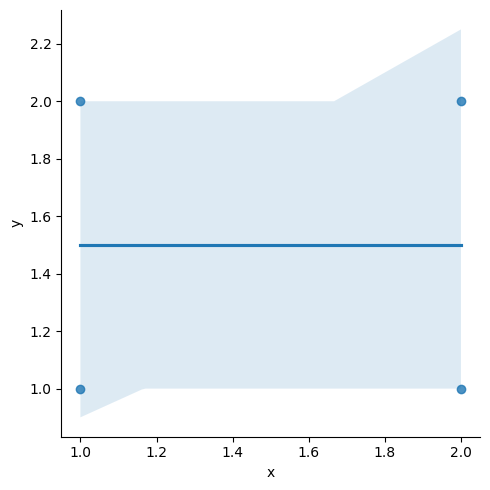

In [ ]:
sns.lmplot(x='x', y='y', data=df)

In [ ]:
df.corr()

,x,y
x,1.0,0.0
y,0.0,1.0
